# MAPPO Stage 1 Training — Multi-UAV Coordination
**Ayesha Khalil | CIIT/SP25-RCS-009/ATD**

### Kaggle pe chalane se pehle:
1. Top right mein **'Edit'** click karo
2. Right panel mein **Session Options → Accelerator → GPU T4 x2** select karo
3. Phir **'Run All'** karo

**Kia hoga:** 3 drones ek 2D map pe apne targets tak pahunchna seekhenge. ~1-2 ghante lagenge.

In [1]:
# Cell 1 — Install libraries
!pip install gymnasium scipy --quiet
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {device}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device    : cuda


In [2]:
# Cell 2 — 2D Environment
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from scipy.optimize import linear_sum_assignment

class MultiUAVEnv(gym.Env):
    def __init__(self, n_drones=3, n_obstacles=0, world_size=100.0,
                 max_speed=5.0, max_steps=300, collision_radius=3.0,
                 target_radius=5.0, seed=None):
        super().__init__()
        self.n_drones        = n_drones
        self.n_obstacles     = n_obstacles
        self.world_size      = world_size
        self.max_speed       = max_speed
        self.max_steps       = max_steps
        self.collision_radius = collision_radius
        self.target_radius   = target_radius
        obs_dim = 10
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                             shape=(n_drones, obs_dim), dtype=np.float32)
        self.action_space = spaces.Box(low=-max_speed, high=max_speed,
                                        shape=(n_drones, 2), dtype=np.float32)
        self.rng = np.random.default_rng(seed)
        self.drone_pos = self.drone_vel = self.target_pos = None
        self.obstacle_pos = np.zeros((0, 2), dtype=np.float32)
        self.assignment = None
        self.step_count = 0

    def reset(self, seed=None, options=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.step_count = 0
        n_total = self.n_drones * 2 + self.n_obstacles
        all_pos = self._sample_non_overlapping(n_total, self.collision_radius * 2)
        self.drone_pos    = all_pos[:self.n_drones].copy()
        self.target_pos   = all_pos[self.n_drones:2*self.n_drones].copy()
        self.obstacle_pos = all_pos[2*self.n_drones:].copy() if self.n_obstacles > 0 else np.zeros((0,2),dtype=np.float32)
        self.drone_vel    = np.zeros((self.n_drones, 2), dtype=np.float32)
        self.assignment   = self._hungarian()
        return self._obs(), {}

    def step(self, actions):
        self.step_count += 1
        self.drone_vel = np.clip(actions, -self.max_speed, self.max_speed).astype(np.float32)
        self.drone_pos = np.clip(self.drone_pos + self.drone_vel, 0.0, self.world_size)
        self.assignment = self._hungarian()
        rewards    = self._rewards()
        reached    = self._all_reached()
        collision  = self._any_collision()
        terminated = reached or collision
        truncated  = self.step_count >= self.max_steps
        info = {'all_targets_reached': reached, 'any_collision': collision,
                'timeout': truncated, 'step': self.step_count}
        return self._obs(), rewards, terminated, truncated, info

    def _obs(self):
        obs = np.zeros((self.n_drones, 10), dtype=np.float32)
        for i in range(self.n_drones):
            rel = self.target_pos[self.assignment[i]] - self.drone_pos[i]
            obs[i] = np.concatenate([self.drone_pos[i], self.drone_vel[i], rel, self._clearances(i)])
        return obs

    def _rewards(self):
        rewards = np.zeros(self.n_drones, dtype=np.float32)
        for i in range(self.n_drones):
            dist = np.linalg.norm(self.drone_pos[i] - self.target_pos[self.assignment[i]])
            r_mission = -dist / self.world_size
            r_safety  = -1.0 if (self._drone_col(i) or self._obs_col(i)) else 0.0
            rewards[i] = 0.5 * r_mission + 0.5 * r_safety
        return rewards

    def _hungarian(self):
        cost = np.linalg.norm(self.drone_pos[:, None] - self.target_pos[None, :], axis=-1)
        _, cols = linear_sum_assignment(cost)
        return cols

    def _drone_col(self, i):
        dists = np.linalg.norm(self.drone_pos[i] - self.drone_pos, axis=-1)
        dists[i] = np.inf
        return bool(np.any(dists < self.collision_radius))

    def _obs_col(self, i):
        if len(self.obstacle_pos) == 0: return False
        return bool(np.any(np.linalg.norm(self.drone_pos[i] - self.obstacle_pos, axis=-1) < self.collision_radius))

    def _any_collision(self):
        return any(self._drone_col(i) or self._obs_col(i) for i in range(self.n_drones))

    def _all_reached(self):
        return all(np.linalg.norm(self.drone_pos[i] - self.target_pos[self.assignment[i]]) <= self.target_radius
                   for i in range(self.n_drones))

    def _clearances(self, i):
        pos = self.drone_pos[i]
        c   = np.array([self.world_size - pos[1], pos[1],
                         self.world_size - pos[0], pos[0]], dtype=np.float32)
        return c / self.world_size

    def _sample_non_overlapping(self, n, min_dist):
        positions, attempts = [], 0
        while len(positions) < n:
            attempts += 1
            if attempts > 10000: raise RuntimeError('World too crowded')
            p = self.rng.uniform(10.0, self.world_size - 10.0, size=2)
            if not any(np.linalg.norm(p - q) < min_dist for q in positions):
                positions.append(p)
        return np.array(positions, dtype=np.float32)

print('Environment ready!')

Environment ready!


In [3]:
# Cell 3 — MAPPO (Actor + Critic + Buffer)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Actor(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, action_dim),
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim))
    def _dist(self, obs):
        return Normal(self.net(obs), self.log_std.exp().expand_as(self.net(obs)))
    def get_action(self, obs):
        d = self._dist(obs); a = d.sample()
        return a, d.log_prob(a).sum(-1)
    def evaluate_action(self, obs, action):
        d = self._dist(obs)
        return d.log_prob(action).sum(-1), d.entropy().sum(-1)

class Critic(nn.Module):
    def __init__(self, global_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

class RolloutBuffer:
    def __init__(self, n_drones, obs_dim, action_dim):
        self.n_drones = n_drones
        self.clear()
    def clear(self):
        self.obs=[]; self.actions=[]; self.rewards=[]
        self.values=[]; self.log_probs=[]; self.dones=[]
    def add(self, obs, actions, rewards, value, log_probs, done):
        self.obs.append(obs.copy()); self.actions.append(actions.copy())
        self.rewards.append(rewards.copy()); self.values.append(float(value))
        self.log_probs.append(log_probs.copy()); self.dones.append(bool(done))
    def __len__(self): return len(self.rewards)
    def compute_gae(self, last_value, gamma=0.99, lam=0.95):
        T = len(self.rewards); n = self.n_drones
        rewards = np.array(self.rewards, dtype=np.float32)
        values  = np.array(self.values,  dtype=np.float32)
        dones   = np.array(self.dones,   dtype=np.float32)
        adv = np.zeros((T, n), dtype=np.float32); last_gae = np.zeros(n, dtype=np.float32)
        for t in reversed(range(T)):
            nv = last_value if t == T-1 else values[t+1]
            m  = 1.0 - dones[t]
            delta = rewards[t] + gamma * nv * m - values[t]
            last_gae = delta + gamma * lam * m * last_gae
            adv[t] = last_gae
        return adv, adv + values[:, np.newaxis]
    def to_tensors(self, device):
        obs = torch.tensor(np.array(self.obs), dtype=torch.float32, device=device)
        act = torch.tensor(np.array(self.actions), dtype=torch.float32, device=device)
        lp  = torch.tensor(np.array(self.log_probs), dtype=torch.float32, device=device)
        return obs, act, lp

class MAPPO:
    def __init__(self, n_drones, obs_dim, action_dim, max_speed,
                 lr=3e-4, gamma=0.99, lam=0.95, clip_eps=0.2,
                 vf_coef=0.5, ent_coef=0.01, n_epochs=10, batch_size=64):
        self.n_drones=n_drones; self.max_speed=max_speed
        self.gamma=gamma; self.lam=lam; self.clip_eps=clip_eps
        self.vf_coef=vf_coef; self.ent_coef=ent_coef
        self.n_epochs=n_epochs; self.batch_size=batch_size
        self.device = DEVICE
        self.actor  = Actor(obs_dim, action_dim).to(DEVICE)
        self.critic = Critic(n_drones * obs_dim).to(DEVICE)
        self.opt    = optim.Adam(list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr)
    @torch.no_grad()
    def get_actions(self, obs_np):
        obs_t = torch.tensor(obs_np, dtype=torch.float32, device=self.device)
        a, lp = self.actor.get_action(obs_t)
        a = a.clamp(-self.max_speed, self.max_speed)
        v = self.critic(obs_t.flatten().unsqueeze(0)).item()
        return a.cpu().numpy(), lp.cpu().numpy(), v
    def update(self, buffer, last_obs_np):
        lo = torch.tensor(last_obs_np, dtype=torch.float32, device=self.device)
        with torch.no_grad(): lv = self.critic(lo.flatten().unsqueeze(0)).item()
        adv_np, ret_np = buffer.compute_gae(lv, self.gamma, self.lam)
        obs_t, act_t, olp_t = buffer.to_tensors(self.device)
        T, n, _ = obs_t.shape
        adv_t = torch.tensor(adv_np, dtype=torch.float32, device=self.device)
        ret_t = torch.tensor(ret_np, dtype=torch.float32, device=self.device)
        af = adv_t.reshape(-1); adv_t = (adv_t - af.mean()) / (af.std() + 1e-8)
        obs_f = obs_t.reshape(T*n,-1); act_f = act_t.reshape(T*n,-1)
        olp_f = olp_t.reshape(T*n); adv_f = adv_t.reshape(T*n); ret_f = ret_t.reshape(T*n)
        gs    = obs_t.reshape(T,-1).unsqueeze(1).expand(T,n,-1).reshape(T*n,-1)
        idx_all = np.arange(T*n)
        al, cl, el = [], [], []
        for _ in range(self.n_epochs):
            np.random.shuffle(idx_all)
            for s in range(0, T*n, self.batch_size):
                idx = idx_all[s:s+self.batch_size]
                lp, ent = self.actor.evaluate_action(obs_f[idx], act_f[idx])
                r = (lp - olp_f[idx]).exp()
                loss_a = -torch.min(r*adv_f[idx], r.clamp(1-self.clip_eps,1+self.clip_eps)*adv_f[idx]).mean()
                loss_c = 0.5*(self.critic(gs[idx]) - ret_f[idx]).pow(2).mean()
                loss   = loss_a + self.vf_coef*loss_c - self.ent_coef*ent.mean()
                self.opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(list(self.actor.parameters())+list(self.critic.parameters()), 0.5)
                self.opt.step()
                al.append(loss_a.item()); cl.append(loss_c.item()); el.append(ent.mean().item())
        buffer.clear()
        return {'actor_loss': np.mean(al), 'critic_loss': np.mean(cl), 'entropy': np.mean(el)}
    def save(self, path):
        torch.save({'actor': self.actor.state_dict(), 'critic': self.critic.state_dict()}, path)

print('MAPPO ready!')

MAPPO ready!


In [4]:
# Cell 4 — Training setup
import os, time, json

# ── Config ──────────────────────────────────────────────────────────
CFG = {
    'n_drones':        3,
    'n_obstacles':     0,       # Stage 1: no obstacles
    'max_speed':       5.0,
    'max_steps':       300,
    'total_episodes':  3000,
    'rollout_steps':   512,
    'eval_every':      100,     # evaluate every 100 episodes
    'eval_episodes':   20,
    'save_every':      500,     # save checkpoint every 500 episodes
    'seed':            42,
    'lr':              3e-4,
    'gamma':           0.99,
    'lam':             0.95,
    'clip_eps':        0.2,
    'vf_coef':         0.5,
    'ent_coef':        0.01,
    'n_epochs':        10,
    'batch_size':      64,
}

np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

train_env = MultiUAVEnv(n_drones=CFG['n_drones'], n_obstacles=CFG['n_obstacles'],
                         max_speed=CFG['max_speed'], max_steps=CFG['max_steps'], seed=CFG['seed'])
eval_env  = MultiUAVEnv(n_drones=CFG['n_drones'], n_obstacles=CFG['n_obstacles'],
                         max_speed=CFG['max_speed'], max_steps=CFG['max_steps'], seed=CFG['seed']+999)

OBS_DIM    = train_env.observation_space.shape[1]   # 10
ACTION_DIM = train_env.action_space.shape[1]         # 2

agent  = MAPPO(CFG['n_drones'], OBS_DIM, ACTION_DIM, CFG['max_speed'],
               lr=CFG['lr'], gamma=CFG['gamma'], lam=CFG['lam'],
               clip_eps=CFG['clip_eps'], vf_coef=CFG['vf_coef'], ent_coef=CFG['ent_coef'],
               n_epochs=CFG['n_epochs'], batch_size=CFG['batch_size'])
buffer = RolloutBuffer(CFG['n_drones'], OBS_DIM, ACTION_DIM)

RESULTS_DIR = '/kaggle/working/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Device     : {DEVICE}')
print(f'Obs dim    : {OBS_DIM}')
print(f'Action dim : {ACTION_DIM}')
print('Setup complete! Ready to train.')

Device     : cuda
Obs dim    : 10
Action dim : 2
Setup complete! Ready to train.


In [5]:
# Cell 5 — TRAIN  (yeh cell 1-2 ghante chalegi)

def collect_rollout(env, agent, buffer, steps):
    obs, _ = env.reset()
    for _ in range(steps):
        actions, log_probs, value = agent.get_actions(obs)
        next_obs, rewards, terminated, truncated, _ = env.step(actions)
        done = terminated or truncated
        buffer.add(obs, actions, rewards, value, log_probs, done)
        obs = next_obs
        if done: obs, _ = env.reset()
    return obs

def evaluate(env, agent, n_eps):
    success = collision = 0
    for _ in range(n_eps):
        obs, _ = env.reset()
        while True:
            actions, _, _ = agent.get_actions(obs)
            obs, _, terminated, truncated, info = env.step(actions)
            if terminated or truncated:
                success   += int(info['all_targets_reached'])
                collision += int(info['any_collision'])
                break
    return success/n_eps, collision/n_eps

def save_history(history, path):
    with open(path, 'w') as f:
        json.dump(history, f, indent=2)

# ── Main loop ───────────────────────────────────────────────────────
history = {'episode':[], 'success':[], 'collision':[], 'actor_loss':[], 'critic_loss':[]}
episode  = 0
update   = 0
steps_per_ep = max(1, CFG['rollout_steps'] // CFG['max_steps'])
start    = time.time()
history_path = f'{RESULTS_DIR}/history.json'

print('Training started!')
print(f'{"Episode":>8} | {"Success":>8} | {"Collision":>10} | {"A-Loss":>8} | {"Time":>6}')
print('-' * 55)

while episode < CFG['total_episodes']:
    last_obs = collect_rollout(train_env, agent, buffer, CFG['rollout_steps'])
    stats    = agent.update(buffer, last_obs)
    episode += steps_per_ep
    update  += 1

    eval_interval = max(1, CFG['eval_every'] // steps_per_ep)
    if update % eval_interval == 0:
        sr, cr  = evaluate(eval_env, agent, CFG['eval_episodes'])
        elapsed = (time.time() - start) / 60
        print(f'{min(episode, CFG["total_episodes"]):>8} | {sr*100:>7.1f}% | {cr*100:>9.1f}% | {stats["actor_loss"]:>+8.4f} | {elapsed:>5.1f}m')
        history['episode'].append(episode)
        history['success'].append(sr)
        history['collision'].append(cr)
        history['actor_loss'].append(stats['actor_loss'])
        history['critic_loss'].append(stats['critic_loss'])
        save_history(history, history_path)   # ← har evaluation pe save

    save_interval = max(1, CFG['save_every'] // steps_per_ep)
    if update % save_interval == 0:
        path = f'{RESULTS_DIR}/checkpoint_ep{episode}.pt'
        agent.save(path)
        print(f'  >> checkpoint saved: {path}')

# Final eval + save
sr, cr = evaluate(eval_env, agent, n_eps=50)
print(f'\n==== TRAINING COMPLETE ====')
print(f'Final Success Rate  : {sr*100:.1f}%')
print(f'Final Collision Rate: {cr*100:.1f}%')

agent.save(f'{RESULTS_DIR}/final_model.pt')
save_history(history, history_path)
print(f'Sab kuch save ho gaya: {RESULTS_DIR}/')

Training started!
 Episode |  Success |  Collision |   A-Loss |   Time
-------------------------------------------------------
     100 |    95.0% |       0.0% |  -0.0067 |   3.0m
     200 |    95.0% |       0.0% |  -0.0010 |   6.1m
     300 |   100.0% |       0.0% |  -0.0044 |   9.1m
     400 |   100.0% |       0.0% |  +0.0954 |  12.1m
     500 |   100.0% |       0.0% |  -0.0237 |  15.1m
  >> checkpoint saved: /kaggle/working/results/checkpoint_ep500.pt
     600 |   100.0% |       0.0% |  -0.0250 |  18.1m
     700 |    95.0% |       5.0% |  +0.0050 |  21.0m
     800 |   100.0% |       0.0% |  -0.0031 |  24.0m
     900 |   100.0% |       0.0% |  +0.0084 |  27.0m
    1000 |   100.0% |       0.0% |  +0.0108 |  30.1m
  >> checkpoint saved: /kaggle/working/results/checkpoint_ep1000.pt
    1100 |    95.0% |       5.0% |  -0.0242 |  33.1m
    1200 |    90.0% |       5.0% |  +0.0354 |  36.1m
    1300 |    90.0% |       5.0% |  +0.0113 |  39.1m
    1400 |   100.0% |       0.0% |  +0.0799 |  42

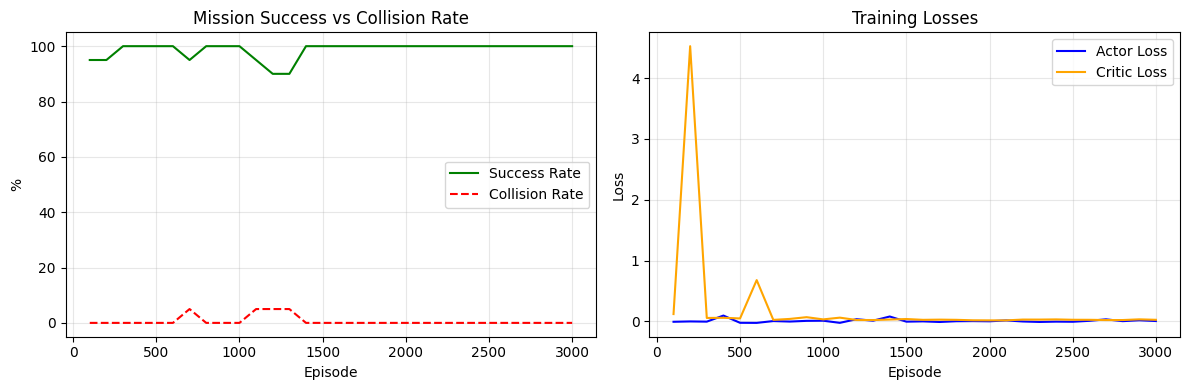

Plot saved!


In [6]:
# Cell 6 — Results plot (training ke baad chalao)
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['episode'], [s*100 for s in history['success']],  color='green', label='Success Rate')
ax1.plot(history['episode'], [c*100 for c in history['collision']], color='red',   label='Collision Rate', linestyle='--')
ax1.set_xlabel('Episode'); ax1.set_ylabel('%')
ax1.set_title('Mission Success vs Collision Rate')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['episode'], history['actor_loss'],  color='blue',   label='Actor Loss')
ax2.plot(history['episode'], history['critic_loss'], color='orange', label='Critic Loss')
ax2.set_xlabel('Episode'); ax2.set_ylabel('Loss')
ax2.set_title('Training Losses')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)
plt.show()
print('Plot saved!')